# Quantum Algorithm Demonstrator

## A Qiskit-Based Toolkit for Fundamental Quantum Algorithms

This notebook demonstrates and compares five fundamental quantum algorithms:

1. Deutsch-Jozsa Algorithm
2. Bernstein-Vazirani Algorithm
3. Simon's Algorithm
4. Grover's Search Algorithm
5. Quantum Fourier Transform (QFT)

The notebook presents:

- Quantum circuit construction
- Circuit visualization
- Quantum simulation results
- Measurement distributions
- Classical vs quantum complexity
- Transpilation analysis

## 1. Introduction

Quantum computing uses quantum mechanical principles to process information.

Unlike classical bits, which can represent either 0 or 1, a qubit can exist in a
superposition of both states. Quantum circuits manipulate qubits using quantum gates
and can exploit superposition, interference, and entanglement.

This project implements five important quantum algorithms using Qiskit and
simulates their execution using a quantum simulator.

### Objectives

- Implement fundamental quantum algorithms using Qiskit.
- Visualize their quantum circuits.
- Execute the circuits using simulation.
- Analyze measurement results.
- Compare classical and quantum complexity.
- Study the effect of circuit transpilation.

In [1]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from algorithms.deutsch_jozsa import deutsch_jozsa_circuit
from algorithms.bernstein_vazirani import bernstein_vazirani_circuit
from algorithms.simon import simon_circuit, valid_measurement, recover_secret
from algorithms.grover import grover_circuit
from algorithms.qft import qft_circuit

from utils.simulator import run_circuit
from utils.visualization import plot_measurement_distribution
from utils.transpiler import transpile_circuit

import matplotlib.pyplot as plt

In [2]:
SHOTS = 1024

print("Quantum Algorithm Demonstrator")
print(f"Simulation shots: {SHOTS}")
print("All modules imported successfully.")

Quantum Algorithm Demonstrator
Simulation shots: 1024
All modules imported successfully.


## 2. Deutsch-Jozsa Algorithm

The Deutsch-Jozsa algorithm determines whether a Boolean function is **constant** or
**balanced** using a quantum oracle.

For the balanced case implemented in this project, the algorithm should produce a
non-zero input measurement rather than `000`.

Deutsch-Jozsa Circuit:


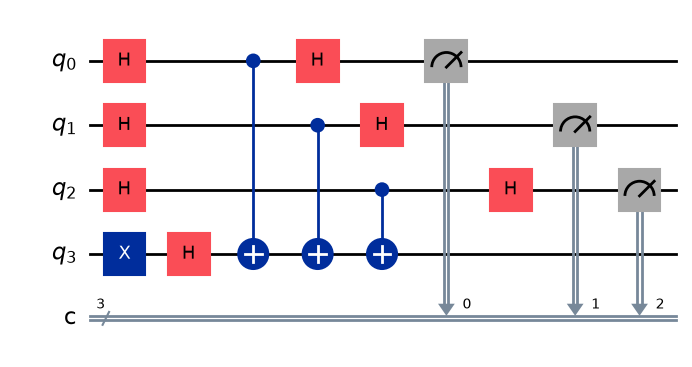

Measurement Results:
{'111': 1024}


In [3]:
dj_circuit = deutsch_jozsa_circuit(3, "balanced")

print("Deutsch-Jozsa Circuit:")
display(dj_circuit.draw("mpl"))

dj_counts = run_circuit(dj_circuit)

print("Measurement Results:")
print(dj_counts)

## 3. Bernstein-Vazirani Algorithm

The Bernstein-Vazirani algorithm identifies a hidden binary string using a quantum
oracle.

For this demonstration, the secret string is `1011`. The quantum circuit should
recover the complete hidden string with a single oracle query.

Bernstein-Vazirani Circuit:


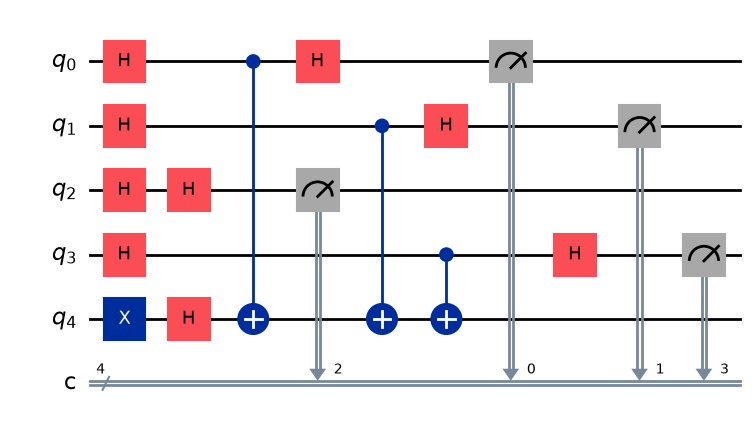

Measurement Results:
{'1011': 1024}
Most probable result: 1011


In [4]:
bv_circuit = bernstein_vazirani_circuit("1011")

print("Bernstein-Vazirani Circuit:")
display(bv_circuit.draw("mpl"))

bv_counts = run_circuit(bv_circuit)

print("Measurement Results:")
print(bv_counts)

print("Most probable result:", max(bv_counts, key=bv_counts.get))


## 4. Simon's Algorithm

Simon's algorithm finds a hidden XOR secret string `s` for a function that satisfies:

f(x) = f(x ⊕ s)

The quantum circuit generates measurement results that satisfy:

y · s = 0

For this demonstration, the hidden secret is `101`.

Simon's Algorithm Circuit:


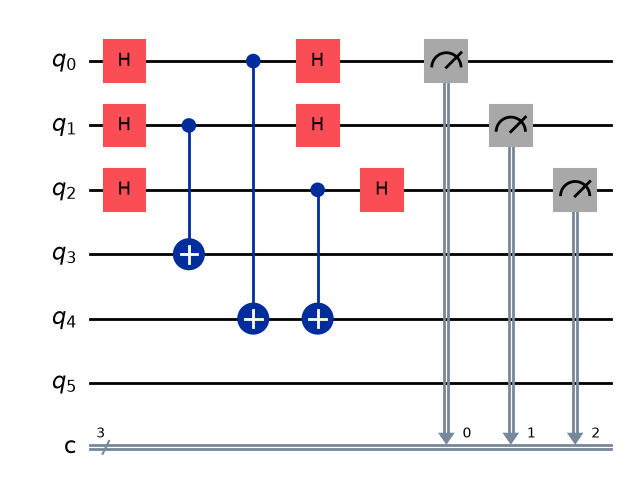

Measurement Results:
{'101': 262, '111': 259, '000': 242, '010': 261}

Checking measurement constraints:
101 -> True
111 -> True
000 -> True
010 -> True


In [5]:
simon_secret = "101"

simon_circuit_result = simon_circuit(simon_secret)

print("Simon's Algorithm Circuit:")
display(simon_circuit_result.draw("mpl"))

simon_counts = run_circuit(simon_circuit_result)

print("Measurement Results:")
print(simon_counts)

print("\nChecking measurement constraints:")

for measurement in simon_counts:
    print(
        measurement,
        "->",
        valid_measurement(measurement, simon_secret)
    )

In [6]:
measurements = list(simon_counts.keys())

recovered_secret = recover_secret(
    measurements,
    3
)

print("Original secret :", simon_secret)
print("Recovered secret:", recovered_secret)

Original secret : 101
Recovered secret: 101


## 5. Grover's Search Algorithm

Grover's algorithm provides a quadratic speedup for searching an unstructured
database.

For N possible items:

- Classical search: O(N)
- Grover's search: O(√N)

For this demonstration, the target state is `101`.

Grover Circuit:


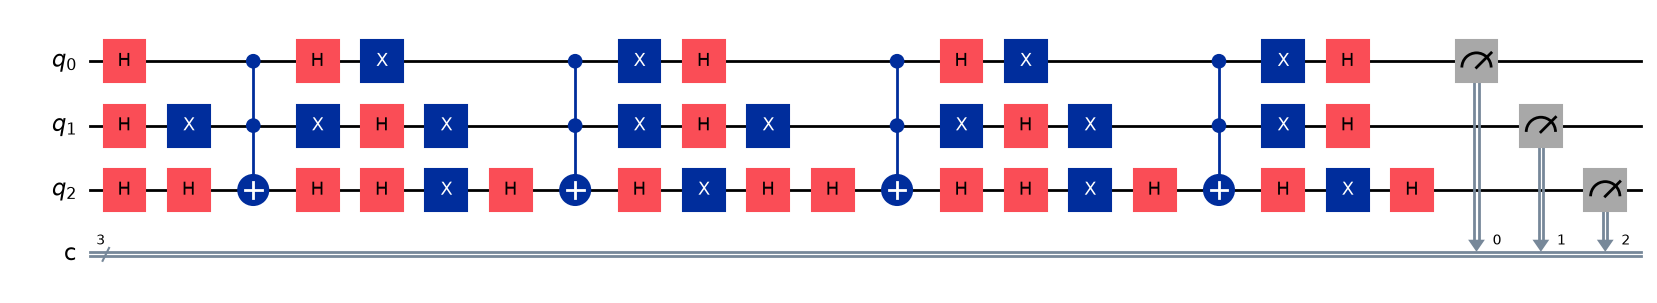

Measurement Results:
{'101': 963, '011': 14, '010': 5, '100': 10, '000': 8, '001': 6, '111': 9, '110': 9}

Target probability: 0.9404296875


In [7]:
grover_target = "101"

grover_circuit_result = grover_circuit(grover_target)

print("Grover Circuit:")
display(grover_circuit_result.draw("mpl"))

grover_counts = run_circuit(grover_circuit_result)

print("Measurement Results:")
print(grover_counts)

print(
    "\nTarget probability:",
    grover_counts.get(grover_target, 0) / SHOTS
)

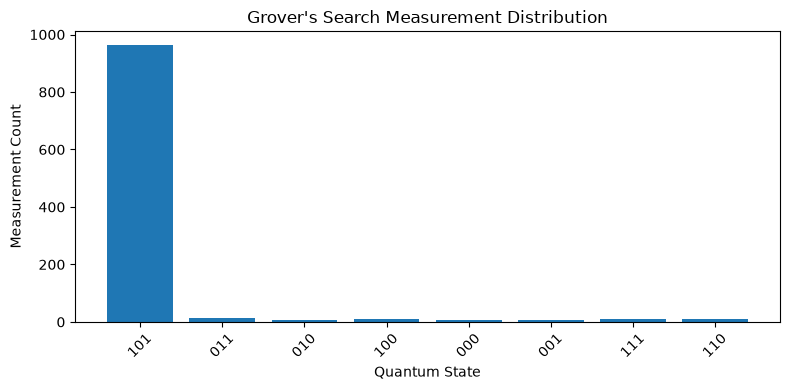

In [8]:
fig = plot_measurement_distribution(grover_counts)

fig.axes[0].set_title(
    "Grover's Search Measurement Distribution"
)

plt.show()

## 6. Quantum Fourier Transform

The Quantum Fourier Transform (QFT) is the quantum analogue of the discrete Fourier
transform.

It is an important building block in several quantum algorithms, including
Shor's algorithm and quantum phase estimation.

The circuit uses:

- Hadamard gates
- Controlled phase rotations
- SWAP gates

Quantum Fourier Transform Circuit:


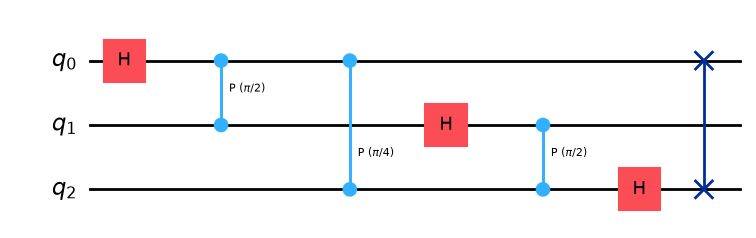

In [9]:
qft_circuit_result = qft_circuit(3)

print("Quantum Fourier Transform Circuit:")
display(qft_circuit_result.draw("mpl"))

In [10]:
qft_measure = qft_circuit_result.copy()

qft_measure.measure_all()

qft_counts = run_circuit(qft_measure)

print("QFT Measurement Results:")
print(qft_counts)

QFT Measurement Results:
{'011': 121, '000': 120, '111': 131, '110': 138, '001': 131, '101': 132, '010': 135, '100': 116}


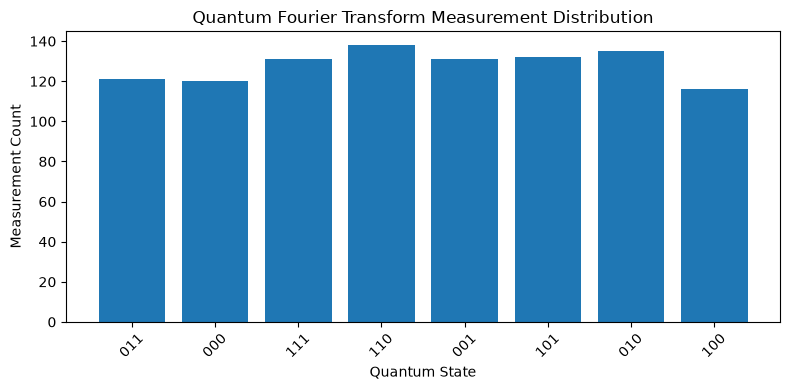

In [11]:
fig = plot_measurement_distribution(qft_counts)

fig.axes[0].set_title(
    "Quantum Fourier Transform Measurement Distribution"
)

plt.show()

## 7. Classical vs Quantum Complexity

The following table compares the theoretical complexity of the implemented
algorithms.

> Note: For Deutsch-Jozsa and Bernstein-Vazirani, the commonly quoted quantum
> complexity refers to **oracle query complexity**. The complete circuit still
> requires gates that scale with the number of qubits.

In [12]:
complexity_data = {
    "Algorithm": [
        "Deutsch-Jozsa",
        "Bernstein-Vazirani",
        "Simon's Algorithm",
        "Grover's Search",
        "QFT"
    ],
    "Classical": [
        "O(2^n)",
        "O(n)",
        "O(2^n)",
        "O(N)",
        "O(n²)"
    ],
    "Quantum": [
        "O(1) query",
        "O(1) query",
        "O(n) queries",
        "O(√N)",
        "O(n²)"
    ]
}

import pandas as pd

complexity_df = pd.DataFrame(complexity_data)

display(complexity_df)

,Algorithm,Classical,Quantum
0,Deutsch-Jozsa,O(2^n),O(1) query
1,Bernstein-Vazirani,O(n),O(1) query
2,Simon's Algorithm,O(2^n),O(n) queries
3,Grover's Search,O(N),O(√N)
4,QFT,O(n²),O(n²)


## 8. Transpilation Analysis

Quantum circuits are transpiled before execution on a specific quantum backend.
Transpilation can rewrite, optimize, and decompose circuit operations.

The following analysis compares the original circuits with circuits transpiled
using Qiskit's optimization level 1.

In [13]:
circuits = {
    "Deutsch-Jozsa": dj_circuit,
    "Bernstein-Vazirani": bv_circuit,
    "Simon": simon_circuit_result,
    "Grover": grover_circuit_result,
    "QFT": qft_circuit_result
}

transpilation_results = []

for name, circuit in circuits.items():

    transpiled = transpile_circuit(
        circuit,
        optimization_level=1
    )

    transpilation_results.append({
        "Algorithm": name,
        "Original Depth": circuit.depth(),
        "Transpiled Depth": transpiled.depth(),
        "Original Gates": len(circuit.data),
        "Transpiled Gates": len(transpiled.data)
    })

transpilation_df = pd.DataFrame(transpilation_results)

display(transpilation_df)

,Algorithm,Original Depth,Transpiled Depth,Original Gates,Transpiled Gates
0,Deutsch-Jozsa,7,6,14,13
1,Bernstein-Vazirani,7,6,17,14
2,Simon,5,5,12,12
3,Grover,22,10,46,21
4,QFT,6,6,7,7


### Transpilation Observation

The transpilation results show that optimization can reduce circuit depth and gate
count.

Grover's circuit shows the largest reduction in this experiment, with the depth
decreasing from 22 to 10 and the gate count decreasing from 46 to 21.

Deutsch-Jozsa and Bernstein-Vazirani also show small reductions. Simon's algorithm
and QFT remain unchanged under the selected transpilation settings.

The results demonstrate that transpilation can optimize a circuit representation
while preserving its intended computation.

## 9. Conclusion

The Quantum Algorithm Demonstrator successfully implements five fundamental quantum
algorithms using Qiskit:

- Deutsch-Jozsa
- Bernstein-Vazirani
- Simon's Algorithm
- Grover's Search
- Quantum Fourier Transform

Each algorithm was constructed as a quantum circuit and executed using simulation.
The resulting measurement distributions were analyzed to verify the expected
behavior.

The project also demonstrates the importance of circuit transpilation and provides
a comparison between classical and quantum computational complexity.

Overall, the toolkit provides an interactive educational environment for
understanding the principles and practical implementation of quantum algorithms.

## 10. Future Enhancements

Possible future improvements include:

- Support for additional quantum algorithms.
- Noisy quantum circuit simulation.
- Execution on real IBM Quantum hardware.
- Interactive circuit parameter controls.
- More advanced circuit optimization analysis.
- Hardware-specific transpilation.
- Expanded visualization and statevector analysis.
- Exporting simulation results and circuit diagrams directly from the interface.

In [14]:
from algorithms.deutsch_jozsa import deutsch_jozsa_circuit
from algorithms.bernstein_vazirani import bernstein_vazirani_circuit
from algorithms.simon import simon_circuit
from algorithms.grover import grover_circuit
from algorithms.qft import qft_circuit

from utils.simulator import run_circuit
from utils.complexity import get_complexity
from utils.visualization import plot_measurement_distribution
from utils.transpiler import transpile_circuit

print("All imports successful!")

All imports successful!
